# Part 2

In [1]:
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [3]:
# read the veteran dataset
df = pd.read_csv('PreProcesseddataset_ifn580_262_v1.csv')

In [4]:
# our goal is is_accepted
# Obtain a list of labels (targets) for each of the samples. We refer to this as 'y'.
y = df["is_accepted"].values
# Remove the label (target) from the samples, as this is not a feature that we want to use to predict against.
# axis=1 is used to drop the column, instead of the row.
X = df.drop(['is_accepted'], axis=1)
# Pull out the column names before grabbing the feature array, we will need it later
feature_names = X.columns
# We use X.values to get arrays for the features, instead of a DataFrame with column names etc.
X = X.values

In [5]:
from sklearn.model_selection import train_test_split
# Create a 50% train/test split from our samples.
# We set the random_state to the constant 10 to ensure it is the same from run-to-run.
# We set the stratisfy parameter to the labels, that way we get an even selection of 0 and 1 values in our testing set.
# Otherwise, we may end up with unbalanced 0/1 labels across the two splits.
random_state = 10
test_set_size = 0.5 # 50%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_set_size,
stratify=y, random_state=random_state)
print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 6342
Size of testing set: 6342


## Test Decision Tree Model

In [6]:
from sklearn.feature_selection import RFECV
import pickle

from sklearn.feature_selection import SelectFromModel
with open('decision_tree_model.pickle', 'rb') as f:
    dt_best, roc_index_dt_cv, fpr_dt_cv, tpr_dt_cv = pickle.load(f)

In [ ]:
print("DT Testing set accuracy:", dt_best.score(X_test, y_test))

y_pred = dt_best.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

DT Testing set accuracy: 0.7136549984232103
              precision    recall  f1-score   support

           0       0.71      0.57      0.63      2737
           1       0.72      0.82      0.77      3605

    accuracy                           0.71      6342
   macro avg       0.71      0.70      0.70      6342
weighted avg       0.71      0.71      0.71      6342



## Test Regression Model

In [9]:
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectFromModel
with open('Logistic_Regression_Model.pickle', 'rb') as f:
     lr_best,roc_index_lr_best, fpr_lr_best, tpr_lr_best,scalerRM = pickle.load(f)
X_test_RM = scalerRM.transform(X_test)

In [10]:
print("RM Test accuracy:", lr_best.score(X_test_RM, y_test))

y_predRM = lr_best.predict(X_test_RM)
print(classification_report(y_test, y_predRM))

# print parameters of the best model
print(lr_best.best_params_)

RM Test accuracy: 0.652160201829076
              precision    recall  f1-score   support

           0       0.63      0.47      0.54      2737
           1       0.66      0.79      0.72      3605

    accuracy                           0.65      6342
   macro avg       0.65      0.63      0.63      6342
weighted avg       0.65      0.65      0.64      6342

{'C': 0.1}


## Test Neural Network Model

In [13]:
from sklearn.feature_selection import SelectFromModel
with open('neural_network_model.pickle', 'rb') as f:
     cv_1,roc_index_cv_1, fpr_cv_1, tpr_cv_1, scalerNN = pickle.load(f)

In [14]:
X_test_sc = scalerNN.transform(X_test)

In [ ]:
print("NN Test accuracy:", cv_1.score(X_test_sc, y_test))

y_pred = cv_1.predict(X_test_sc)

print(classification_report(y_test, y_pred))
print(cv_1.best_params_)

NN Test accuracy: 0.7250078839482813
              precision    recall  f1-score   support

           0       0.70      0.63      0.67      2737
           1       0.74      0.79      0.77      3605

    accuracy                           0.73      6342
   macro avg       0.72      0.71      0.72      6342
weighted avg       0.72      0.73      0.72      6342

{'hidden_layer_sizes': (45,)}


## Evaluate via ROC

In [21]:
from sklearn.metrics import roc_auc_score

y_pred_proba_dt = dt_best.predict_proba(X_test)
y_pred_proba_RM = lr_best.predict_proba(X_test_RM)
y_pred_proba_NN = cv_1.predict_proba(X_test_sc)

roc_index_dt = roc_auc_score(y_test, y_pred_proba_dt[:, 1])
roc_index_RM = roc_auc_score(y_test, y_pred_proba_RM[:, 1])
roc_index_NN = roc_auc_score(y_test, y_pred_proba_NN[:, 1])

print("ROC index on test for DT:", roc_index_dt)
print("ROC index on test for RM:", roc_index_RM)
print("ROC index on test for NN:", roc_index_NN)

ROC index on test for DT: 0.7627198958941955
ROC index on test for RM: 0.69408425252752
ROC index on test for NN: 0.7901073641782589


In [ ]:
from sklearn.metrics import roc_curve

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt[:,1])
fpr_RM, tpr_RM, thresholds_RM = roc_curve(y_test, y_pred_proba_RM[:,1])
fpr_NN, tpr_NN, thresholds_NN = roc_curve(y_test, y_pred_proba_NN[:,1])

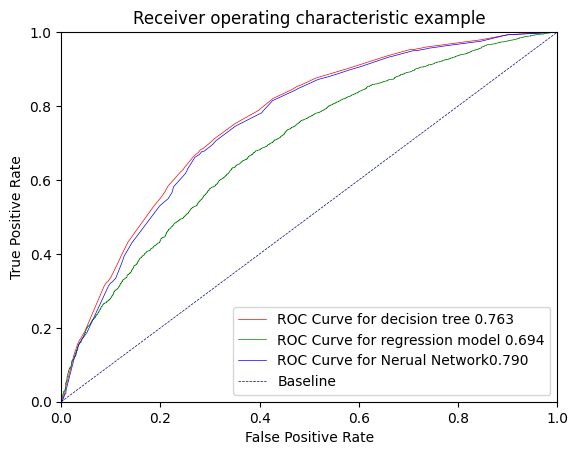

In [ ]:
plt.plot(fpr_dt, tpr_dt, label='ROC Curve for decision tree {:.3f}'.format(roc_index_dt), color='red', lw=0.5)
plt.plot(fpr_RM, tpr_RM, label='ROC Curve for regression model {:.3f}'.format(roc_index_RM), color='green', lw=0.5)
plt.plot(fpr_dt_cv, tpr_dt_cv, label='ROC Curve for Nerual Network{:.3f}'.format(roc_index_NN), color='blue', lw=0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=0.5, label='Baseline', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

plt.show()

## Summary Table

In [23]:
#print summary table for each model
summary_table = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Neural Network'],
    'Test Accuracy': [dt_best.score(X_test, y_test), lr_best.score(X_test_RM, y_test), cv_1.score(X_test_sc, y_test)],
    'ROC Index': [roc_index_dt, roc_index_RM, roc_index_NN]
})

print(summary_table)

                 Model  Test Accuracy  ROC Index
0        Decision Tree       0.713655   0.762720
1  Logistic Regression       0.652160   0.694084
2       Neural Network       0.725008   0.790107
